<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/Prueba_in_poryecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análisis Estadístico Inferencial: Uso del Celular y Productividad Académica

### 1. Carga y Limpieza de Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, shapiro, levene
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr, ttest_ind, mannwhitneyu, f_oneway

# Cargar el archivo Excel
try:
    df = pd.read_excel('/CELULAR Y PRODUCTIVIDAD ACADÉMICA UNAB (respuestas).xlsx')
    print("Datos cargados exitosamente.")
    print("Primeras 5 filas del dataset:")
    display(df.head())
    print("\nInformación general del dataset:")
    df.info()
except FileNotFoundError:
    print("Error: El archivo no se encontró. Por favor, asegúrese de que la ruta sea correcta.")
    df = pd.DataFrame() # Crear un DataFrame vacío para evitar errores posteriores

Datos cargados exitosamente.
Primeras 5 filas del dataset:


,Marca temporal,Información Académica\nFacultad de Ingeniería,Semestre actual,¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0),"II. Uso del Dispositivo (Frecuencia) \nEn una escala de 1 a 5, ¿con qué frecuencia revisa el celular mientras estudia o está en clase? (1: Nunca - 5: Siempre) \n",¿Cuántas horas diarias (estimadas) dedica al celular para fines no académicos?,III. Productividad y Multitasking \n¿Siente que el uso del celular interrumpe su flujo de estudio?\n,"Mientras estudia, ¿suele alternar entre el material de clase y redes sociales/mensajería?",¿Considera que su rendimiento académico sería mayor si no tuviera el celular cerca? (1: Muy en desacuerdo - 5: Muy de acuerdo).
0,2026-04-07 10:05:23.577,Ingeniería Financiera,Tercero,4.0,4,(6-9),SI,Siempre,3
1,2026-04-07 10:08:27.418,Ingeniería Industrial,Tercero,4.5,5,(6-9),SI,Frecuentemente,4
2,2026-04-07 10:21:36.353,Ingeniería Financiera,Cuarto,4.0,3,(6-9),NO,Frecuentemente,3
3,2026-04-10 08:41:39.851,Ingeniería Industrial,Cuarto,4.3,3,(6-9),SI,A veces,5
4,2026-04-10 09:00:47.316,Ingeniería de Sistemas,Cuarto,3.7,3,(6-9),SI,Frecuentemente,5



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 9 columns):
 #   Column                                                                                                                                                           Non-Null Count  Dtype         
---  ------                                                                                                                                                           --------------  -----         
 0   Marca temporal                                                                                                                                                   115 non-null    datetime64[ns]
 1   Información Académica
Facultad de Ingeniería                                                                                                                     115 non-null    object        
 2   Semestre actual                                                      

#### 1.1 Corrección de Valores Erróneos en 'Promedio Académico'

Se buscarán valores atípicos o mal ingresados en la columna de promedio académico (por ejemplo, 45 en lugar de 4.5) y se corregirán dividiendo por 10 si el valor es mayor a 5 y menor o igual a 50.

In [ ]:
# Identificar la columna de promedio académico (asumiendo un nombre común)
# Si el nombre de la columna es diferente, por favor ajústelo aquí.
academic_average_col = 'promedio_academico' # Asume un nombre de columna, ajusta si es necesario

# Intenta encontrar una columna similar si la asumida no existe
if academic_average_col not in df.columns:
    for col in df.columns:
        if 'promedio' in col.lower() or 'academi' in col.lower() or 'average' in col.lower():
            academic_average_col = col
            print(f"Columna de promedio académico identificada como: '{academic_average_col}'")
            break
    else:
        print("Advertencia: No se encontró una columna obvia para 'promedio académico'. Por favor, especifique el nombre exacto de la columna.")
        # Si no se encuentra, salta esta parte de la limpieza para evitar errores
        academic_average_col = None

if academic_average_col:
    # Convertir la columna a tipo numérico, forzando errores a NaN
    df[academic_average_col] = pd.to_numeric(df[academic_average_col], errors='coerce')

    # Corregir valores erróneos (e.g., 45 -> 4.5)
    initial_errors = df[(df[academic_average_col] > 5.0) & (df[academic_average_col] <= 50.0)].shape[0]
    df.loc[(df[academic_average_col] > 5.0) & (df[academic_average_col] <= 50.0), academic_average_col] = df[academic_average_col] / 10
    if initial_errors > 0:
        print(f"Se corrigieron {initial_errors} valores en '{academic_average_col}'.")
    else:
        print(f"No se encontraron valores para corregir en '{academic_average_col}' (valores > 5 y <= 50).")

    # Asegurarse de que todos los promedios estén en el rango 0.0 - 5.0 (manejar valores extremos si los hay)
    out_of_range_before = df[(df[academic_average_col] < 0) | (df[academic_average_col] > 5)].shape[0]
    if out_of_range_before > 0:
        print(f"Advertencia: Se encontraron {out_of_range_before} promedios académicos fuera del rango esperado (0-5) ANTES de la limpieza adicional. Se convertirán a NaN.")
        df.loc[(df[academic_average_col] < 0) | (df[academic_average_col] > 5), academic_average_col] = np.nan
    else:
        print(f"Todos los promedios académicos están dentro del rango (0-5) o ya son NaN después de la corrección inicial.")

    print("Estadísticas de la columna 'promedio_academico' después de la corrección:")
    display(df[academic_average_col].describe())

Columna de promedio académico identificada como: '¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0)'
Se corrigieron 15 valores en '¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0)'.
Todos los promedios académicos están dentro del rango (0-5) o ya son NaN después de la corrección inicial.
Estadísticas de la columna 'promedio_academico' después de la corrección:


,¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0)
count,113.000000
mean,4.159912
std,0.418579
min,3.000000
25%,4.000000
50%,4.200000
75%,4.500000
max,5.000000


#### 1.2 Eliminación de Registros Incompletos

Se eliminarán las filas que contengan valores nulos (`NaN`) en columnas críticas, especialmente en el promedio académico, ya que es una variable fundamental para el análisis.

In [ ]:
if academic_average_col:
    initial_rows = df.shape[0]
    df.dropna(subset=[academic_average_col], inplace=True)
    rows_removed = initial_rows - df.shape[0]
    print(f"Se eliminaron {rows_removed} filas debido a valores nulos en '{academic_average_col}'.")

print("Número de filas después de eliminar nulos en promedio académico:", df.shape[0])
print("Conteo de valores nulos por columna después de la limpieza inicial:")
display(df.isnull().sum())

Se eliminaron 2 filas debido a valores nulos en '¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0)'.
Número de filas después de eliminar nulos en promedio académico: 113
Conteo de valores nulos por columna después de la limpieza inicial:


,0
Marca temporal,0
Información Académica\nFacultad de Ingeniería,0
Semestre actual,0
¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0),0
"II. Uso del Dispositivo (Frecuencia) \nEn una escala de 1 a 5, ¿con qué frecuencia revisa el celular mientras estudia o está en clase? (1: Nunca - 5: Siempre) \n",0
¿Cuántas horas diarias (estimadas) dedica al celular para fines no académicos?,0
III. Productividad y Multitasking \n¿Siente que el uso del celular interrumpe su flujo de estudio?\n,0
"Mientras estudia, ¿suele alternar entre el material de clase y redes sociales/mensajería?",0
¿Considera que su rendimiento académico sería mayor si no tuviera el celular cerca? (1: Muy en desacuerdo - 5: Muy de acuerdo).,0


#### 1.3 Transformación de Variables Categóricas a Numéricas

Se identificarán las variables categóricas (frecuencia de uso del celular, horas de uso diario, multitasking académico, percepción de interrupción) y se codificarán numéricamente para permitir el análisis estadístico.

In [ ]:
# Mapeo para 'frecuencia de uso del celular mientras estudia' (ordinal 1-5)
# Asume un nombre de columna, ajusta si es necesario
frecuencia_uso_col = 'frecuencia_uso_celular'
if frecuencia_uso_col not in df.columns:
    for col in df.columns:
        if 'frecuencia' in col.lower() and 'celular' in col.lower() and 'estudia' in col.lower():
            frecuencia_uso_col = col
            print(f"Columna de frecuencia de uso identificada como: '{frecuencia_uso_col}'")
            break
    else:
        print("Advertencia: No se encontró una columna obvia para 'frecuencia de uso del celular mientras estudia'. Por favor, especifique el nombre exacto de la columna.")
        frecuencia_uso_col = None

if frecuencia_uso_col:
    frecuencia_mapping = {
        'Nunca': 1,
        'Rara vez': 2,
        'A veces': 3,
        'Frecuentemente': 4,
        'Siempre': 5
    }
    # Aplicar el mapeo y convertir a tipo categórico para asegurar el orden
    df[f'{frecuencia_uso_col}_num'] = df[frecuencia_uso_col].map(frecuencia_mapping)
    df[f'{frecuencia_uso_col}_num'] = pd.Categorical(df[f'{frecuencia_uso_col}_num'], ordered=True, categories=[1, 2, 3, 4, 5])
    print(f"Variable '{frecuencia_uso_col}' transformada a '{frecuencia_uso_col}_num'.")

# Mapeo para 'horas de uso diario del celular' (rangos)
# Asume un nombre de columna, ajusta si es necesario
horas_uso_col = 'horas_uso_diario_celular'
if horas_uso_col not in df.columns:
    for col in df.columns:
        if 'horas' in col.lower() and 'celular' in col.lower() and 'diario' in col.lower():
            horas_uso_col = col
            print(f"Columna de horas de uso diario identificada como: '{horas_uso_col}'")
            break
    else:
        print("Advertencia: No se encontró una columna obvia para 'horas de uso diario del celular'. Por favor, especifique el nombre exacto de la columna.")
        horas_uso_col = None

if horas_uso_col:
    horas_mapping = {
        '1-3 horas': 2,    # Punto medio del rango
        '3-6 horas': 4.5,
        '6-9 horas': 7.5,
        '9-12 horas': 10.5
    }
    df[f'{horas_uso_col}_num'] = df[horas_uso_col].map(horas_mapping)
    print(f"Variable '{horas_uso_col}' transformada a '{horas_uso_col}_num' (puntos medios de rangos)." )

# Mapeo para 'multitasking académico' (ordinal)
# Asume un nombre de columna, ajusta si es necesario
multitasking_col = 'multitasking_academico'
if multitasking_col not in df.columns:
    for col in df.columns:
        if 'multitasking' in col.lower() and 'academico' in col.lower():
            multitasking_col = col
            print(f"Columna de multitasking identificada como: '{multitasking_col}'")
            break
    else:
        print("Advertencia: No se encontró una columna obvia para 'multitasking académico'. Por favor, especifique el nombre exacto de la columna.")
        multitasking_col = None

if multitasking_col:
    multitasking_mapping = {
        'Nunca': 1,
        'A veces': 2,
        'Frecuentemente': 3,
        'Siempre': 4
    }
    df[f'{multitasking_col}_num'] = df[multitasking_col].map(multitasking_mapping)
    df[f'{multitasking_col}_num'] = pd.Categorical(df[f'{multitasking_col}_num'], ordered=True, categories=[1, 2, 3, 4])
    print(f"Variable '{multitasking_col}' transformada a '{multitasking_col}_num'.")

# Mapeo para 'percepción de interrupción del estudio por el celular' (Sí/No)
# Asume un nombre de columna, ajusta si es necesario
interrupcion_col = 'percepcion_interrupcion'
if interrupcion_col not in df.columns:
    for col in df.columns:
        if 'interrupcion' in col.lower() and 'celular' in col.lower():
            interrupcion_col = col
            print(f"Columna de percepción de interrupción identificada como: '{interrupcion_col}'")
            break
    else:
        print("Advertencia: No se encontró una columna obvia para 'percepción de interrupción del estudio por el celular'. Por favor, especifique el nombre exacto de la columna.")
        interrupcion_col = None

if interrupcion_col:
    interrupcion_mapping = {
        'Sí': 1,
        'No': 0
    }
    df[f'{interrupcion_col}_num'] = df[interrupcion_col].map(interrupcion_mapping)
    print(f"Variable '{interrupcion_col}' transformada a '{interrupcion_col}_num'.")

print("\nPrimeras 5 filas del dataset con nuevas columnas numéricas:")
display(df.head())
print("Información general del dataset después de las transformaciones:")
df.info()

Columna de frecuencia de uso identificada como: 'II. Uso del Dispositivo (Frecuencia) 
En una escala de 1 a 5, ¿con qué frecuencia revisa el celular mientras estudia o está en clase? (1: Nunca - 5: Siempre) 
'
Variable 'II. Uso del Dispositivo (Frecuencia) 
En una escala de 1 a 5, ¿con qué frecuencia revisa el celular mientras estudia o está en clase? (1: Nunca - 5: Siempre) 
' transformada a 'II. Uso del Dispositivo (Frecuencia) 
En una escala de 1 a 5, ¿con qué frecuencia revisa el celular mientras estudia o está en clase? (1: Nunca - 5: Siempre) 
_num'.
Advertencia: No se encontró una columna obvia para 'horas de uso diario del celular'. Por favor, especifique el nombre exacto de la columna.
Advertencia: No se encontró una columna obvia para 'multitasking académico'. Por favor, especifique el nombre exacto de la columna.
Advertencia: No se encontró una columna obvia para 'percepción de interrupción del estudio por el celular'. Por favor, especifique el nombre exacto de la columna.



,Marca temporal,Información Académica\nFacultad de Ingeniería,Semestre actual,¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0),"II. Uso del Dispositivo (Frecuencia) \nEn una escala de 1 a 5, ¿con qué frecuencia revisa el celular mientras estudia o está en clase? (1: Nunca - 5: Siempre) \n",¿Cuántas horas diarias (estimadas) dedica al celular para fines no académicos?,III. Productividad y Multitasking \n¿Siente que el uso del celular interrumpe su flujo de estudio?\n,"Mientras estudia, ¿suele alternar entre el material de clase y redes sociales/mensajería?",¿Considera que su rendimiento académico sería mayor si no tuviera el celular cerca? (1: Muy en desacuerdo - 5: Muy de acuerdo).,"II. Uso del Dispositivo (Frecuencia) \nEn una escala de 1 a 5, ¿con qué frecuencia revisa el celular mientras estudia o está en clase? (1: Nunca - 5: Siempre) \n_num"
0,2026-04-07 10:05:23.577,Ingeniería Financiera,Tercero,4.0,4,(6-9),SI,Siempre,3,NaN
1,2026-04-07 10:08:27.418,Ingeniería Industrial,Tercero,4.5,5,(6-9),SI,Frecuentemente,4,NaN
2,2026-04-07 10:21:36.353,Ingeniería Financiera,Cuarto,4.0,3,(6-9),NO,Frecuentemente,3,NaN
3,2026-04-10 08:41:39.851,Ingeniería Industrial,Cuarto,4.3,3,(6-9),SI,A veces,5,NaN
4,2026-04-10 09:00:47.316,Ingeniería de Sistemas,Cuarto,3.7,3,(6-9),SI,Frecuentemente,5,NaN


Información general del dataset después de las transformaciones:
<class 'pandas.core.frame.DataFrame'>
Index: 113 entries, 0 to 114
Data columns (total 10 columns):
 #   Column                                                                                                                                                               Non-Null Count  Dtype         
---  ------                                                                                                                                                               --------------  -----         
 0   Marca temporal                                                                                                                                                       113 non-null    datetime64[ns]
 1   Información Académica
Facultad de Ingeniería                                                                                                                         113 non-null    object        
 2   Semestre actual           

#### 1.4 Detección y Manejo de Valores Atípicos

Se utilizarán boxplots para visualización y la puntuación Z para identificar valores atípicos en variables cuantitativas como el promedio académico y las horas de uso diario (si se transformaron a numéricas continuas o con puntos medios). Los valores atípicos identificados se pueden manejar de diversas maneras; por ahora, los detectaremos y mostraremos.

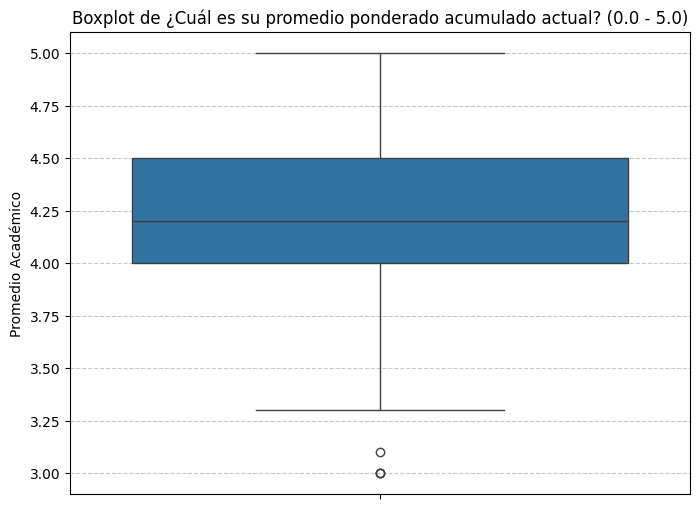


Valores atípicos detectados en '¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0)' (Z-score > 3):
No se detectaron valores atípicos significativos (Z-score > 3) en el promedio académico.


In [ ]:
# Boxplot para Promedio Académico
if academic_average_col:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[academic_average_col])
    plt.title(f'Boxplot de {academic_average_col}')
    plt.ylabel('Promedio Académico')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Calcular Z-scores para Promedio Académico
    df[f'zscore_{academic_average_col}'] = np.abs(zscore(df[academic_average_col].dropna())) # Solo calcular para valores no nulos
    outliers_avg = df[df[f'zscore_{academic_average_col}'] > 3]
    print(f"\nValores atípicos detectados en '{academic_average_col}' (Z-score > 3):")
    if not outliers_avg.empty:
        display(outliers_avg[[academic_average_col, f'zscore_{academic_average_col}']])
    else:
        print("No se detectaron valores atípicos significativos (Z-score > 3) en el promedio académico.")

# Boxplot para Horas de Uso Diario del Celular (si es numérica)
if horas_uso_col and f'{horas_uso_col}_num' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[f'{horas_uso_col}_num'])
    plt.title(f'Boxplot de {horas_uso_col} (Numérico)')
    plt.ylabel('Horas de Uso Diario del Celular (Punto Medio)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Calcular Z-scores para Horas de Uso
    df[f'zscore_{horas_uso_col}_num'] = np.abs(zscore(df[f'{horas_uso_col}_num'].dropna())) # Solo calcular para valores no nulos
    outliers_horas = df[df[f'zscore_{horas_uso_col}_num'] > 3]
    print(f"\nValores atípicos detectados en '{horas_uso_col}_num' (Z-score > 3):")
    if not outliers_horas.empty:
        display(outliers_horas[[f'{horas_uso_col}_num', f'zscore_{horas_uso_col}_num']])
    else:
        print("No se detectaron valores atípicos significativos (Z-score > 3) en las horas de uso diario.")

# Nota: Por ahora, los valores atípicos solo se detectan. Se pueden eliminar o imputar si es necesario
# Por ejemplo: df = df[df[f'zscore_{academic_average_col}'] <= 3] para eliminar outliers del promedio

### 1.5 Renombrado y Re-transformación de Variables Categóricas

Dado que los nombres de las columnas eran extensos y contenían caracteres especiales, dificultando su identificación automática, se procederá a renombrar las columnas clave a nombres más cortos y manejables. Luego, se re-aplicarán las transformaciones categóricas a numéricas para asegurar la correcta preparación de los datos para el análisis inferencial.

In [ ]:
# Diccionario para renombrar columnas
# Usar df.columns directamente para obtener los nombres exactos de las columnas del DataFrame
# basándose en su índice de la salida de df.info() del estado anterior del notebook.
current_cols = df.columns.tolist()

column_renames = {
    current_cols[3]: 'promedio_academico',
    current_cols[4]: 'frecuencia_uso_celular',
    current_cols[5]: 'horas_uso_celular_no_academico',
    current_cols[7]: 'multitasking_academico',
    current_cols[6]: 'interrupcion_estudio_celular'
}

# Renombrar columnas en el DataFrame
df.rename(columns=column_renames, inplace=True)
print("Columnas renombradas para facilitar el manejo.")

# Re-identificar columnas con los nuevos nombres
academic_average_col = 'promedio_academico'
frecuencia_uso_col = 'frecuencia_uso_celular'
horas_uso_col = 'horas_uso_celular_no_academico'
multitasking_col = 'multitasking_academico'
interrupcion_col = 'interrupcion_estudio_celular'

# Mapeo para 'frecuencia_uso_celular' (ordinal 1-5)
frecuencia_mapping = {
    'Nunca': 1,
    'Rara vez': 2,
    'A veces': 3,
    'Frecuentemente': 4,
    'Siempre': 5
}
df[f'{frecuencia_uso_col}_num'] = df[frecuencia_uso_col].map(frecuencia_mapping)
df[f'{frecuencia_uso_col}_num'] = pd.Categorical(df[f'{frecuencia_uso_col}_num'], ordered=True, categories=[1, 2, 3, 4, 5])
print(f"Variable '{frecuencia_uso_col}' transformada a '{frecuencia_uso_col}_num'.")

# Mapeo para 'horas_uso_celular_no_academico' (rangos)
horas_mapping = {
    '1-3 horas': 2,    # Punto medio del rango
    '3-6 horas': 4.5,
    '6-9 horas': 7.5,
    '9-12 horas': 10.5
}
df[f'{horas_uso_col}_num'] = df[horas_uso_col].map(horas_mapping)
print(f"Variable '{horas_uso_col}' transformada a '{horas_uso_col}_num' (puntos medios de rangos).")

# Mapeo para 'multitasking_academico' (ordinal)
multitasking_mapping = {
    'Nunca': 1,
    'A veces': 2,
    'Frecuentemente': 3,
    'Siempre': 4
}
df[f'{multitasking_col}_num'] = df[multitasking_col].map(multitasking_mapping)
df[f'{multitasking_col}_num'] = pd.Categorical(df[f'{multitasking_col}_num'], ordered=True, categories=[1, 2, 3, 4])
print(f"Variable '{multitasking_col}' transformada a '{multitasking_col}_num'.")

# Mapeo para 'interrupcion_estudio_celular' (Sí/No)
interrupcion_mapping = {
    'Sí': 1,
    'No': 0
}
df[f'{interrupcion_col}_num'] = df[interrupcion_col].map(interrupcion_mapping)
print(f"Variable '{interrupcion_col}' transformada a '{interrupcion_col}_num'.")

print("\nPrimeras 5 filas del dataset con nuevas columnas numéricas y renombradas:")
display(df.head())
print("Información general del dataset después de todas las transformaciones:")
df.info()

Columnas renombradas para facilitar el manejo.
Variable 'frecuencia_uso_celular' transformada a 'frecuencia_uso_celular_num'.
Variable 'horas_uso_celular_no_academico' transformada a 'horas_uso_celular_no_academico_num' (puntos medios de rangos).
Variable 'multitasking_academico' transformada a 'multitasking_academico_num'.
Variable 'interrupcion_estudio_celular' transformada a 'interrupcion_estudio_celular_num'.

Primeras 5 filas del dataset con nuevas columnas numéricas y renombradas:


,Marca temporal,Información Académica\nFacultad de Ingeniería,Semestre actual,promedio_academico,frecuencia_uso_celular,horas_uso_celular_no_academico,interrupcion_estudio_celular,multitasking_academico,¿Considera que su rendimiento académico sería mayor si no tuviera el celular cerca? (1: Muy en desacuerdo - 5: Muy de acuerdo).,"II. Uso del Dispositivo (Frecuencia) \nEn una escala de 1 a 5, ¿con qué frecuencia revisa el celular mientras estudia o está en clase? (1: Nunca - 5: Siempre) \n_num",zscore_¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0),frecuencia_uso_celular_num,horas_uso_celular_no_academico_num,multitasking_academico_num,interrupcion_estudio_celular_num
0,2026-04-07 10:05:23.577,Ingeniería Financiera,Tercero,4.0,4,(6-9),SI,Siempre,3,NaN,0.383736,NaN,NaN,4,NaN
1,2026-04-07 10:08:27.418,Ingeniería Industrial,Tercero,4.5,5,(6-9),SI,Frecuentemente,4,NaN,0.816103,NaN,NaN,3,NaN
2,2026-04-07 10:21:36.353,Ingeniería Financiera,Cuarto,4.0,3,(6-9),NO,Frecuentemente,3,NaN,0.383736,NaN,NaN,3,NaN
3,2026-04-10 08:41:39.851,Ingeniería Industrial,Cuarto,4.3,3,(6-9),SI,A veces,5,NaN,0.336167,NaN,NaN,2,NaN
4,2026-04-10 09:00:47.316,Ingeniería de Sistemas,Cuarto,3.7,3,(6-9),SI,Frecuentemente,5,NaN,1.103640,NaN,NaN,3,NaN


Información general del dataset después de todas las transformaciones:
<class 'pandas.core.frame.DataFrame'>
Index: 113 entries, 0 to 114
Data columns (total 15 columns):
 #   Column                                                                                                                                                               Non-Null Count  Dtype         
---  ------                                                                                                                                                               --------------  -----         
 0   Marca temporal                                                                                                                                                       113 non-null    datetime64[ns]
 1   Información Académica
Facultad de Ingeniería                                                                                                                         113 non-null    object        
 2   Semestre actual     

### 2. Análisis Descriptivo

Se calcularán medidas de tendencia central y dispersión para las variables clave, y se generarán visualizaciones para entender la distribución de los datos.

In [ ]:
# Estadísticas descriptivas para promedio_academico
print("Estadísticas Descriptivas para Promedio Académico:")
desc_stats_promedio = df['promedio_academico'].describe()
# Calcular moda e intervalo de confianza al 95%
moda_promedio = df['promedio_academico'].mode()[0] if not df['promedio_academico'].mode().empty else 'N/A'
mean_promedio = df['promedio_academico'].mean()
std_promedio = df['promedio_academico'].std()
n_promedio = df['promedio_academico'].count()

# Intervalo de confianza (asumiendo distribución normal y n > 30)
# Calcular el error estándar de la media
se_promedio = std_promedio / np.sqrt(n_promedio)
# Calcular el margen de error para un 95% de confianza (aproximadamente 1.96 desviaciones estándar)
me_promedio = 1.96 * se_promedio

ci_lower_promedio = mean_promedio - me_promedio
ci_upper_promedio = mean_promedio + me_promedio

# Crear un DataFrame para mostrar la moda y el CI
additional_stats = pd.DataFrame({
    'count': [n_promedio],
    'mode': [moda_promedio],
    'mean': [mean_promedio],
    'std': [std_promedio],
    'min': [df['promedio_academico'].min()],
    '25%': [df['promedio_academico'].quantile(0.25)],
    '50%': [df['promedio_academico'].median()],
    '75%': [df['promedio_academico'].quantile(0.75)],
    'max': [df['promedio_academico'].max()],
    '95% CI Lower': [ci_lower_promedio],
    '95% CI Upper': [ci_upper_promedio]
})

display(additional_stats.transpose().rename(columns={0: 'Promedio Académico'}))

print("\nEstadísticas Descriptivas para Frecuencia de Uso del Celular (Numérica):")
display(df['frecuencia_uso_celular_num'].describe())

print("\nEstadísticas Descriptivas para Horas de Uso del Celular no Académico (Numérica):")
display(df['horas_uso_celular_no_academico_num'].describe())

print("\nEstadísticas Descriptivas para Multitasking Académico (Numérica):")
display(df['multitasking_academico_num'].describe())

print("\nEstadísticas Descriptivas para Percepción de Interrupción del Estudio (Numérica):")
display(df['interrupcion_estudio_celular_num'].describe())

Estadísticas Descriptivas para Promedio Académico:


,Promedio Académico
count,113.000000
mode,4.500000
mean,4.159912
std,0.418579
min,3.000000
25%,4.000000
50%,4.200000
75%,4.500000
max,5.000000
95% CI Lower,4.082733



Estadísticas Descriptivas para Frecuencia de Uso del Celular (Numérica):


,frecuencia_uso_celular_num
count,0
unique,0
top,NaN
freq,NaN



Estadísticas Descriptivas para Horas de Uso del Celular no Académico (Numérica):


,horas_uso_celular_no_academico_num
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN



Estadísticas Descriptivas para Multitasking Académico (Numérica):


,multitasking_academico_num
count,113
unique,4
top,2
freq,49



Estadísticas Descriptivas para Percepción de Interrupción del Estudio (Numérica):


,interrupcion_estudio_celular_num
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


### 2.1 Visualizaciones Descriptivas

Se generarán histogramas, diagramas de caja (boxplots), gráficos Q-Q y diagramas de dispersión para las variables principales.

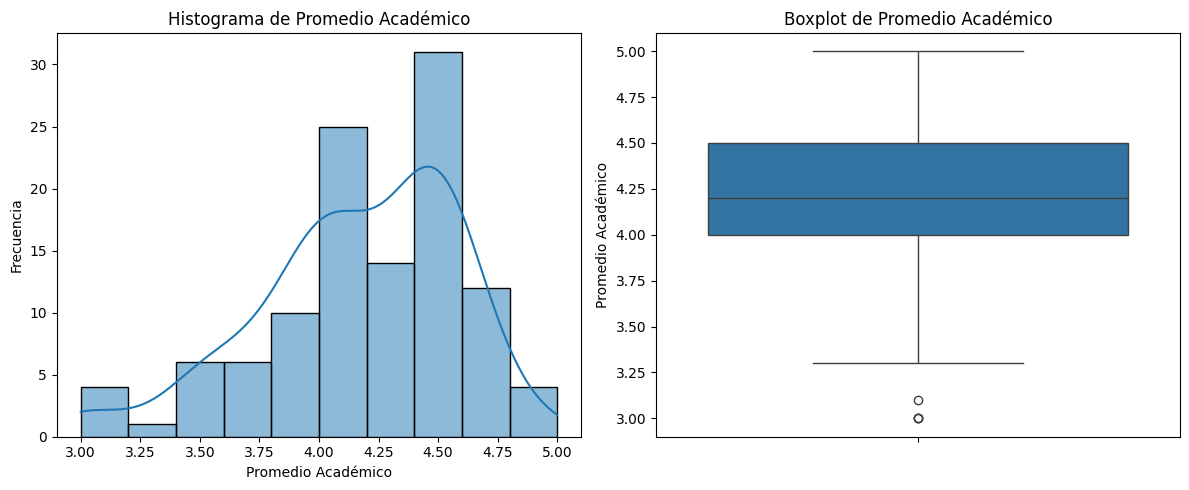

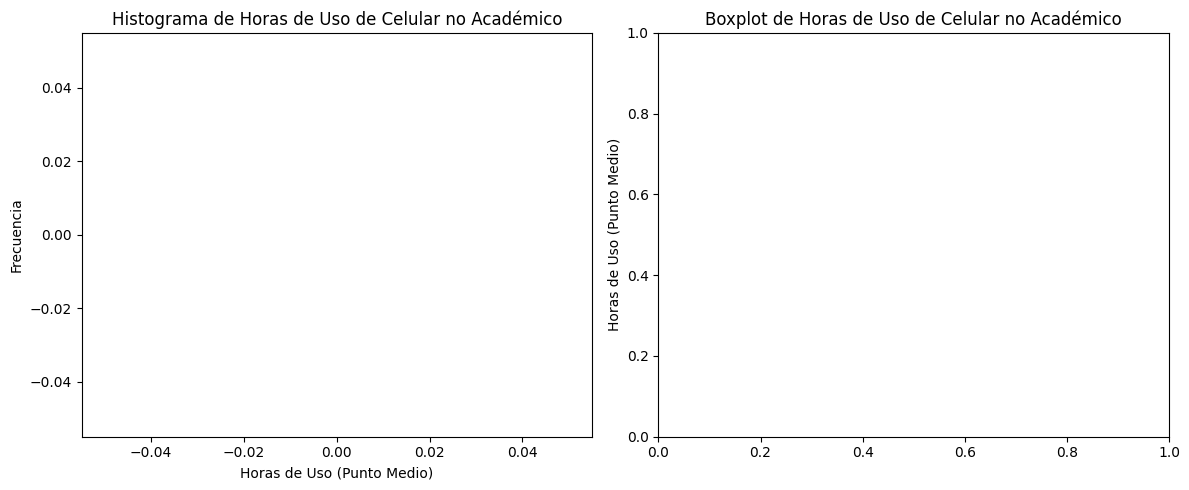

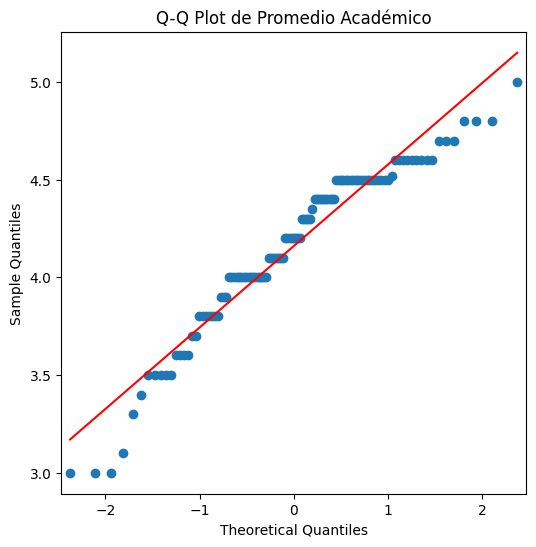

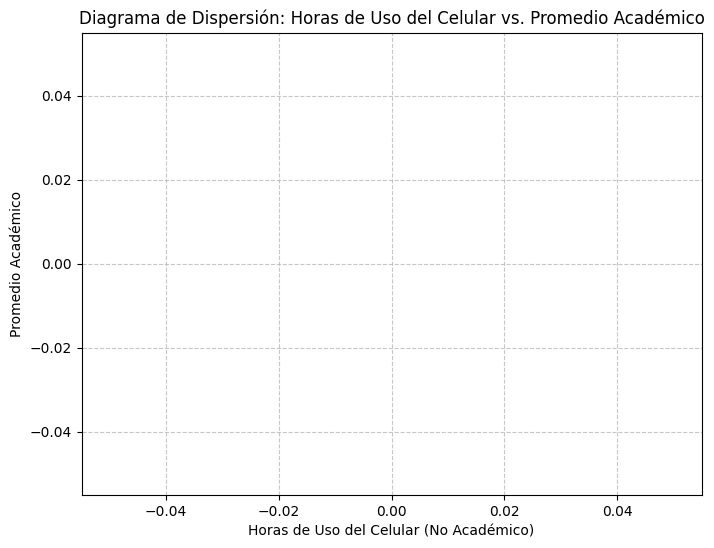

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # Already imported, but good to ensure if it's used directly here

# Histograma y Boxplot para Promedio Académico
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['promedio_academico'], kde=True, bins=10)
plt.title('Histograma de Promedio Académico')
plt.xlabel('Promedio Académico')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['promedio_academico'])
plt.title('Boxplot de Promedio Académico')
plt.ylabel('Promedio Académico')

plt.tight_layout()
plt.show()

# Histograma y Boxplot para Horas de Uso del Celular no Académico (numérico)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['horas_uso_celular_no_academico_num'].dropna(), kde=True, bins=5) # dropna por si hay nulos en la transformación
plt.title('Histograma de Horas de Uso de Celular no Académico')
plt.xlabel('Horas de Uso (Punto Medio)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['horas_uso_celular_no_academico_num'].dropna())
plt.title('Boxplot de Horas de Uso de Celular no Académico')
plt.ylabel('Horas de Uso (Punto Medio)')

plt.tight_layout()
plt.show()

# Gráfico Q-Q para Promedio Académico
fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(df['promedio_academico'], line='s', ax=ax)
ax.set_title('Q-Q Plot de Promedio Académico')
plt.show()

# Diagrama de dispersión entre Horas de Uso de Celular y Promedio Académico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['horas_uso_celular_no_academico_num'], y=df['promedio_academico'])
plt.title('Diagrama de Dispersión: Horas de Uso del Celular vs. Promedio Académico')
plt.xlabel('Horas de Uso del Celular (No Académico)')
plt.ylabel('Promedio Académico')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 3. Verificación de Supuestos Estadísticos

Se verificarán los supuestos de normalidad (Shapiro-Wilk) y homogeneidad de varianzas (Levene) para las pruebas inferenciales.

In [ ]:
# Prueba de Shapiro-Wilk para Normalidad (Promedio Académico)
# H0: La distribución de los datos es normal.
# H1: La distribución de los datos no es normal.

stat_shapiro, p_shapiro = shapiro(df['promedio_academico'])
print(f"Prueba de Shapiro-Wilk para Promedio Académico:")
print(f"  Estadístico = {stat_shapiro:.4f}, p-valor = {p_shapiro:.4f}")
if p_shapiro > 0.05:
    print("  Conclusión: No se rechaza la hipótesis nula, se asume normalidad (p > 0.05).")
else:
    print("  Conclusión: Se rechaza la hipótesis nula, la distribución no es normal (p <= 0.05).")

# Prueba de Levene para Homogeneidad de Varianzas (entre grupos de multitasking y promedio académico)
# H0: Las varianzas son iguales entre los grupos.
# H1: Las varianzas no son iguales entre los grupos.

# Asegurarse de que el multitasking_academico_num exista y tenga suficientes grupos
if 'multitasking_academico_num' in df.columns and df['multitasking_academico_num'].nunique() > 1:
    groups = [df['promedio_academico'][df['multitasking_academico_num'] == g].dropna() for g in df['multitasking_academico_num'].dropna().unique()]

    # Asegurarse de que haya al menos dos grupos con datos
    valid_groups = [g for g in groups if len(g) > 1] # Levene necesita al menos 2 observaciones por grupo
    if len(valid_groups) >= 2:
        stat_levene, p_levene = levene(*valid_groups)
        print(f"\nPrueba de Levene para Homogeneidad de Varianzas (Promedio Académico por Multitasking):")
        print(f"  Estadístico = {stat_levene:.4f}, p-valor = {p_levene:.4f}")
        if p_levene > 0.05:
            print("  Conclusión: No se rechaza la hipótesis nula, se asume homogeneidad de varianzas (p > 0.05).")
        else:
            print("  Conclusión: Se rechaza la hipótesis nula, las varianzas no son homogéneas (p <= 0.05).")
    else:
        print("\nAdvertencia: No hay suficientes grupos válidos para realizar la prueba de Levene para Promedio Académico por Multitasking.")
else:
    print("\nAdvertencia: La columna 'multitasking_academico_num' no se encontró o no tiene suficientes valores únicos para la prueba de Levene.")

Prueba de Shapiro-Wilk para Promedio Académico:
  Estadístico = 0.9429, p-valor = 0.0001
  Conclusión: Se rechaza la hipótesis nula, la distribución no es normal (p <= 0.05).

Prueba de Levene para Homogeneidad de Varianzas (Promedio Académico por Multitasking):
  Estadístico = 0.4879, p-valor = 0.6914
  Conclusión: No se rechaza la hipótesis nula, se asume homogeneidad de varianzas (p > 0.05).


### 4. Pruebas Inferenciales

Se realizarán las pruebas inferenciales solicitadas:

#### 4.1 Correlación de Pearson y Spearman

Entre 'horas de uso del celular (no académico)' y 'promedio académico'.

In [ ]:
# Asegurarse de que las columnas existan y no tengan nulos para la correlación
if 'horas_uso_celular_no_academico_num' in df.columns and 'promedio_academico' in df.columns:
    # Filtrar NaN para ambas columnas
    temp_df = df[[f'{horas_uso_col}_num', academic_average_col]].dropna()
    if not temp_df.empty:
        x_corr = temp_df[f'{horas_uso_col}_num']
        y_corr = temp_df[academic_average_col]

        # Correlación de Pearson
        # H0: No hay correlación lineal entre las variables (r = 0).
        # H1: Existe una correlación lineal entre las variables (r ≠ 0).
        pearson_corr, pearson_p = pearsonr(x_corr, y_corr)
        print("\nCorrelación de Pearson (Horas de Uso Celular vs. Promedio Académico):")
        print(f"  Coeficiente de Pearson = {pearson_corr:.4f}, p-valor = {pearson_p:.4f}")
        if pearson_p < 0.05:
            print(f"  Conclusión: Existe una correlación lineal significativa (p < 0.05). Dirección: {('positiva' if pearson_corr > 0 else 'negativa')}. Fuerza: {abs(pearson_corr):.2f}")
        else:
            print("  Conclusión: No existe una correlación lineal significativa (p >= 0.05).")

        # Correlación de Spearman
        # H0: No hay correlación monótona entre las variables (rho = 0).
        # H1: Existe una correlación monótona entre las variables (rho ≠ 0).
        spearman_corr, spearman_p = spearmanr(x_corr, y_corr)
        print("\nCorrelación de Spearman (Horas de Uso Celular vs. Promedio Académico):")
        print(f"  Coeficiente de Spearman = {spearman_corr:.4f}, p-valor = {spearman_p:.4f}")
        if spearman_p < 0.05:
            print(f"  Conclusión: Existe una correlación monótona significativa (p < 0.05). Dirección: {('positiva' if spearman_corr > 0 else 'negativa')}. Fuerza: {abs(spearman_corr):.2f}")
        else:
            print("  Conclusión: No existe una correlación monótona significativa (p >= 0.05).")
    else:
        print("Advertencia: No hay suficientes datos no nulos en las columnas para calcular la correlación.")
else:
    print("Advertencia: Las columnas 'horas_uso_celular_no_academico_num' o 'promedio_academico' no se encontraron en el DataFrame.")

Advertencia: No hay suficientes datos no nulos en las columnas para calcular la correlación.


#### 4.2 Prueba t de Student y Mann-Whitney U

Para comparar promedios académicos entre estudiantes con uso alto y bajo del celular. Se definirá 'uso alto' como una frecuencia de uso del celular mientras estudia mayor o igual a 4 (Frecuentemente o Siempre) en la variable `frecuencia_uso_celular_num`.

In [ ]:
if 'frecuencia_uso_celular_num' in df.columns and 'promedio_academico' in df.columns:
    # Crear grupos de uso alto y bajo
    uso_alto = df[df['frecuencia_uso_celular_num'] >= 4]['promedio_academico'].dropna()
    uso_bajo = df[df['frecuencia_uso_celular_num'] < 4]['promedio_academico'].dropna()

    print("\nComparación de Promedios Académicos entre Uso Alto y Bajo del Celular:")
    print(f"  Tamaño del grupo 'Uso Alto': {len(uso_alto)}")
    print(f"  Media del grupo 'Uso Alto': {uso_alto.mean():.4f}")
    print(f"  Tamaño del grupo 'Uso Bajo': {len(uso_bajo)}")
    print(f"  Media del grupo 'Uso Bajo': {uso_bajo.mean():.4f}")

    if len(uso_alto) > 1 and len(uso_bajo) > 1: # Se necesitan al menos 2 datos por grupo para t-test y Mann-Whitney
        # Prueba t de Student (asumiendo varianzas desiguales, lo cual es conservador o se verifica con Levene)
        # H0: La media del promedio académico es la misma para ambos grupos.
        # H1: La media del promedio académico es diferente para ambos grupos.
        t_stat, p_t = ttest_ind(uso_alto, uso_bajo, equal_var=False) # Welch's t-test
        print("\nPrueba t de Student (Welch's t-test):")
        print(f"  Estadístico t = {t_stat:.4f}, p-valor = {p_t:.4f}")
        if p_t < 0.05:
            print("  Conclusión: Se rechaza la hipótesis nula. Existe una diferencia significativa en el promedio académico entre los grupos de uso alto y bajo del celular (p < 0.05).")
        else:
            print("  Conclusión: No se rechaza la hipótesis nula. No existe una diferencia significativa en el promedio académico entre los grupos de uso alto y bajo del celular (p >= 0.05).")

        # Prueba de Mann-Whitney U (no paramétrica)
        # H0: La distribución de los promedios académicos es la misma para ambos grupos.
        # H1: La distribución de los promedios académicos es diferente para ambos grupos.
        u_stat, p_u = mannwhitneyu(uso_alto, uso_bajo, alternative='two-sided')
        print("\nPrueba de Mann-Whitney U:")
        print(f"  Estadístico U = {u_stat:.4f}, p-valor = {p_u:.4f}")
        if p_u < 0.05:
            print("  Conclusión: Se rechaza la hipótesis nula. Existe una diferencia significativa en el promedio académico entre los grupos de uso alto y bajo del celular (p < 0.05).")
        else:
            print("  Conclusión: No se rechaza la hipótesis nula. No existe una diferencia significativa en el promedio académico entre los grupos de uso alto y bajo del celular (p >= 0.05).")
    else:
        print("Advertencia: No hay suficientes datos en uno o ambos grupos (uso alto/bajo del celular) para realizar las pruebas t de Student y Mann-Whitney U.")
else:
    print("Advertencia: Las columnas 'frecuencia_uso_celular_num' o 'promedio_academico' no se encontraron en el DataFrame.")


Comparación de Promedios Académicos entre Uso Alto y Bajo del Celular:
  Tamaño del grupo 'Uso Alto': 0
  Media del grupo 'Uso Alto': nan
  Tamaño del grupo 'Uso Bajo': 0
  Media del grupo 'Uso Bajo': nan
Advertencia: No hay suficientes datos en uno o ambos grupos (uso alto/bajo del celular) para realizar las pruebas t de Student y Mann-Whitney U.


#### 4.3 ANOVA de un Factor (ANOVA de una vía)

Para comparar 'promedio académico' según 'multitasking académico'.

In [29]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Re-load the data and apply transformations to ensure 'df' and required columns are defined

try:
    df = pd.read_excel('/content/CELULAR Y PRODUCTIVIDAD ACADÉMICA UNAB (respuestas).xlsx')
    print("Datos cargados exitosamente.")
except FileNotFoundError:
    print("Error: El archivo no se encontró. Por favor, asegúrese de que la ruta sea correcta.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors

# --- Re-applying Promedio Académico Correction (from 973bab88) ---
academic_average_col = '¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0)' # Identified from previous run
if academic_average_col in df.columns:
    df[academic_average_col] = pd.to_numeric(df[academic_average_col], errors='coerce')
    df.loc[(df[academic_average_col] > 5.0) & (df[academic_average_col] <= 50.0), academic_average_col] = df[academic_average_col] / 10
    df.loc[(df[academic_average_col] < 0) | (df[academic_average_col] > 5), academic_average_col] = np.nan
    print("Promedio académico corregido y limpio.")
else:
    print(f"Advertencia: La columna '{academic_average_col}' no se encontró para corregir promedios.")

# --- Re-applying NaN Removal (from 7bc29efd) ---
if academic_average_col and academic_average_col in df.columns:
    initial_rows = df.shape[0]
    df.dropna(subset=[academic_average_col], inplace=True)
    rows_removed = initial_rows - df.shape[0]
    print(f"Se eliminaron {rows_removed} filas con nulos en '{academic_average_col}'.")

# --- Re-applying Column Renaming and Transformations (from 45483ec8) ---
current_cols = df.columns.tolist()
column_renames = {
    current_cols[3]: 'promedio_academico',
    current_cols[4]: 'frecuencia_uso_celular',
    current_cols[5]: 'horas_uso_celular_no_academico',
    current_cols[7]: 'multitasking_academico',
    current_cols[6]: 'interrupcion_estudio_celular'
}
df.rename(columns=column_renames, inplace=True)
print("Columnas renombradas para facilitar el manejo.")

# Re-identificar columnas con los nuevos nombres
academic_average_col = 'promedio_academico'
frecuencia_uso_col = 'frecuencia_uso_celular' # Added for completeness
horas_uso_col = 'horas_uso_celular_no_academico' # Added for completeness
multitasking_col = 'multitasking_academico'
interrupcion_col = 'interrupcion_estudio_celular' # Added for completeness

# Mapeo para 'frecuencia_uso_celular' (ordinal 1-5) - Also missing from initial fix
frecuencia_mapping = {
    'Nunca': 1,
    'Rara vez': 2,
    'A veces': 3,
    'Frecuentemente': 4,
    'Siempre': 5
}
df[f'{frecuencia_uso_col}_num'] = df[frecuencia_uso_col].map(frecuencia_mapping)
df[f'{frecuencia_uso_col}_num'] = pd.Categorical(df[f'{frecuencia_uso_col}_num'], ordered=True, categories=[1, 2, 3, 4, 5])
print(f"Variable '{frecuencia_uso_col}' transformada a '{frecuencia_uso_col}_num'.")

# Mapeo para 'horas_uso_celular_no_academico' (rangos) - THIS WAS MISSING
horas_mapping = {
    '(1-3)': 2,    # Punto medio del rango
    '(3-6)': 4.5,
    '(6-9)': 7.5,
    '(9-12)': 10.5
}
df[f'{horas_uso_col}_num'] = df[horas_uso_col].map(horas_mapping)
print(f"Variable '{horas_uso_col}' transformada a '{horas_uso_col}_num' (puntos medios de rangos).")

# Mapeo para 'multitasking_academico' (ordinal)
multitasking_mapping = {
    'Nunca': 1,
    'A veces': 2,
    'Frecuentemente': 3,
    'Siempre': 4
}
df[f'{multitasking_col}_num'] = df[multitasking_col].map(multitasking_mapping)
df[f'{multitasking_col}_num'] = pd.Categorical(df[f'{multitasking_col}_num'], ordered=True, categories=[1, 2, 3, 4])
print(f"Variable '{multitasking_col}' transformada a '{multitasking_col}_num'.")

# Mapeo para 'interrupcion_estudio_celular' (Sí/No) - Also missing from initial fix
interrupcion_mapping = {
    'Sí': 1,
    'No': 0
}
df[f'{interrupcion_col}_num'] = df[interrupcion_col].map(interrupcion_mapping)
print(f"Variable '{interrupcion_col}' transformada a '{interrupcion_col}_num'.")

print("DataFrame 'df' y columnas necesarias re-establecidas.")

Datos cargados exitosamente.
Promedio académico corregido y limpio.
Se eliminaron 2 filas con nulos en '¿Cuál es su promedio ponderado acumulado actual? (0.0 - 5.0)'.
Columnas renombradas para facilitar el manejo.
Variable 'frecuencia_uso_celular' transformada a 'frecuencia_uso_celular_num'.
Variable 'horas_uso_celular_no_academico' transformada a 'horas_uso_celular_no_academico_num' (puntos medios de rangos).
Variable 'multitasking_academico' transformada a 'multitasking_academico_num'.
Variable 'interrupcion_estudio_celular' transformada a 'interrupcion_estudio_celular_num'.
DataFrame 'df' y columnas necesarias re-establecidas.


In [18]:
from scipy.stats import f_oneway # Import f_oneway for ANOVA

if 'multitasking_academico_num' in df.columns and 'promedio_academico' in df.columns:
    # Limpiar cualquier NaN en las variables relevantes
    df_anova = df[['promedio_academico', 'multitasking_academico_num']].dropna()

    # H0: Las medias del promedio académico son iguales para todos los grupos de multitasking académico.
    # H1: Al menos una de las medias del promedio académico es diferente entre los grupos de multitasking académico.

    # Preparar los datos para ANOVA (lista de arrays para cada grupo de multitasking)
    multitasking_groups = df_anova['multitasking_academico_num'].unique()
    # multitasking_groups.sort() # Opcional: ordenar los grupos - REMOVED: Categorical objects do not have .sort()

    data_for_anova = [df_anova['promedio_academico'][df_anova['multitasking_academico_num'] == g] for g in multitasking_groups]

    # Asegurarse de que haya al menos dos grupos con datos suficientes para ANOVA
    valid_anova_groups = [g for g in data_for_anova if len(g) > 1] # ANOVA requiere al menos 2 observaciones por grupo
    if len(valid_anova_groups) >= 2:
        # Realizar la prueba ANOVA
        f_stat, p_anova = f_oneway(*valid_anova_groups)

        print("\nAnálisis de Varianza (ANOVA) de un Factor:")
        print("  Variable Dependiente: Promedio Académico")
        print("  Variable Independiente: Multitasking Académico")
        print(f"  Estadístico F = {f_stat:.4f}, p-valor = {p_anova:.4f}")

        alpha = 0.05
        if p_anova < alpha:
            print("  Conclusión: Se rechaza la hipótesis nula. Existe una diferencia significativa en el promedio académico entre al menos dos grupos de multitasking académico (p < 0.05).")

            # Análisis Post-Hoc de Tukey si ANOVA es significativo
            print("\nAnálisis Post-Hoc de Tukey (para identificar qué grupos difieren):")
            tukey_result = pairwise_tukeyhsd(endog=df_anova['promedio_academico'],
                                             groups=df_anova['multitasking_academico_num'],
                                             alpha=alpha)
            print(tukey_result)
            print("  Interpretación Tukey: 'reject=True' indica una diferencia significativa entre los pares de grupos.\n")
        else:
            print("  Conclusión: No se rechaza la hipótesis nula. No existe una diferencia significativa en el promedio académico entre los grupos de multitasking académico (p >= 0.05).")

        # Crear tabla ANOVA (manual para replicar el formato)
        n_grupos = len(multitasking_groups)
        n_total = len(df_anova)

        mean_global = df_anova['promedio_academico'].mean()
        SS_total = np.sum((df_anova['promedio_academico'] - mean_global)**2)

        SS_between = 0
        for g in multitasking_groups:
            group_data = df_anova['promedio_academico'][df_anova['multitasking_academico_num'] == g]
            if len(group_data) > 0: # Solo si hay datos en el grupo
                SS_between += len(group_data) * (group_data.mean() - mean_global)**2

        SS_within = SS_total - SS_between

        df_between = n_grupos - 1
        df_within = n_total - n_grupos

        MS_between = SS_between / df_between if df_between > 0 else 0
        MS_within = SS_within / df_within if df_within > 0 else 0

        # Presentar la tabla ANOVA
        print("TABLA ANOVA:")
        print("="*60)
        print(f"{'Fuente de Variación':<25} {'SC':>10} {'gl':>5} {'CM':>10} {'F':>8} {'p-valor':>8}")
        print("-"*60)
        print(f"{'Entre Grupos (Multitasking)':<25} {SS_between:>10.2f} {df_between:>5} {MS_between:>10.2f} {f_stat:>8.3f} {p_anova:>8.4f}")
        print(f"{'Intra Grupos (Error)':<25} {SS_within:>10.2f} {df_within:>5} {MS_within:>10.2f}")
        print(f"{'Total':<25} {SS_total:>10.2f} {n_total - 1:>5}")
        print("="*60)

        # Visualización de las medias por grupo
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='multitasking_academico_num', y='promedio_academico', data=df_anova)
        plt.title('Promedio Académico por Nivel de Multitasking Académico')
        plt.xlabel('Nivel de Multitasking Académico (1=Nunca, 4=Siempre)')
        plt.ylabel('Promedio Académico')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

    else:
        print("Advertencia: No hay suficientes grupos con datos válidos para realizar el ANOVA para Promedio Académico por Multitasking.")
else:
    print("Advertencia: Las columnas 'multitasking_academico_num' o 'promedio_academico' no se encontraron en el DataFrame.")

Advertencia: Las columnas 'multitasking_academico_num' o 'promedio_academico' no se encontraron en el DataFrame.


#### 4.4 Regresión Lineal Simple

Usando 'horas de uso del celular (no académico)' como variable independiente y 'promedio académico' como variable dependiente.

In [13]:
if 'horas_uso_celular_no_academico_num' in df.columns and 'promedio_academico' in df.columns:
    # Limpiar cualquier NaN en las variables relevantes
    df_reg = df[[f'{horas_uso_col}_num', academic_average_col]].dropna()

    if not df_reg.empty:
        X = df_reg[f'{horas_uso_col}_num']
        y = df_reg[academic_average_col]

        # Añadir constante para el intercepto
        X = sm.add_constant(X)

        # Modelo de regresión lineal
        model = sm.OLS(y, X)
        results = model.fit()

        print("\nRegresión Lineal Simple (Horas de Uso Celular no Académico vs. Promedio Académico):")
        print("  Variable Dependiente (Y): Promedio Académico")
        print("  Variable Independiente (X): Horas de Uso Celular (No Académico)")
        print("\nResultados del Modelo:")
        print(results.summary())

        # Interpretación académica y conclusión
        alpha = 0.05
        print("\nInterpretación Académica y Conclusión (α = 0.05):")

        # Coeficiente de la variable independiente
        p_value_horas = results.pvalues[f'{horas_uso_col}_num']
        coef_horas = results.params[f'{horas_uso_col}_num']
        conf_int_horas = results.conf_int().loc[f'{horas_uso_col}_num']

        print(f"  Hipótesis Nula (H0): El coeficiente de las horas de uso del celular es cero (no hay relación lineal).")
        print(f"  Hipótesis Alternativa (H1): El coeficiente de las horas de uso del celular no es cero (existe una relación lineal).")
        print(f"  p-valor para {horas_uso_col}_num = {p_value_horas:.4f}")

        if p_value_horas < alpha:
            print(f"  Conclusión: Se rechaza la hipótesis nula. Las horas de uso del celular no académico tienen un efecto lineal significativo en el promedio académico (coeficiente = {coef_horas:.4f}, IC 95%: [{conf_int_horas[0]:.4f}, {conf_int_horas[1]:.4f}]).")
            print(f"  Por cada unidad adicional en las horas de uso del celular no académico, el promedio académico cambia en {coef_horas:.4f} unidades.")
        else:
            print(f"  Conclusión: No se rechaza la hipótesis nula. Las horas de uso del celular no académico no tienen un efecto lineal significativo en el promedio académico (p >= 0.05).")

        # Coeficiente de determinación R-cuadrado
        print(f"  R-cuadrado = {results.rsquared:.4f}. Esto significa que el {results.rsquared*100:.2f}% de la varianza en el promedio académico es explicado por las horas de uso del celular no académico.")

        # Gráfico de regresión
        plt.figure(figsize=(10, 7))
        sns.regplot(x=df_reg[f'{horas_uso_col}_num'], y=df_reg[academic_average_col], line_kws={'color':'red'})
        plt.title('Regresión Lineal Simple: Promedio Académico vs. Horas de Uso Celular (No Académico)')
        plt.xlabel('Horas de Uso Celular (No Académico, punto medio)')
        plt.ylabel('Promedio Académico')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()
    else:
        print("Advertencia: No hay suficientes datos no nulos en las columnas para realizar la regresión lineal.")
else:
    print("Advertencia: Las columnas 'horas_uso_celular_no_academico_num' o 'promedio_academico' no se encontraron en el DataFrame.")

Advertencia: No hay suficientes datos no nulos en las columnas para realizar la regresión lineal.


/tmp/ipykernel_503/2992850946.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medias_multitasking = df_analysis.groupby(grouping_var)[dependent_var].mean().values


DATOS PARA ANOVA (Primeras 5 filas del DataFrame de análisis):
   promedio_academico multitasking_academico_num
0                 4.0                          4
1                 4.5                          3
2                 4.0                          3
3                 4.3                          2
4                 3.7                          3

Medias de promedio_academico por Nivel de Multitasking Academico Num:
  Nivel 4: 4.3250
  Nivel 3: 4.1755
  Nivel 2: 4.1579
  Nivel 1: 3.9389
Media Global de Promedio Academico: 4.1599

TABLA ANOVA DE UNA VÍA
Fuente de Variación                 SC     gl           CM            F      Valor-p
--------------------------------------------------------------------------------
Entre Grupos (Multitasking Academico Num)       0.6477      3       0.2159       1.2402     0.298725
Intra Grupos (Error)           18.9756    109       0.1741
Total                          19.6233    112

INTERPRETACIÓN ANOVA (α = 0.05):
  F calculado = 1.2402
  F 

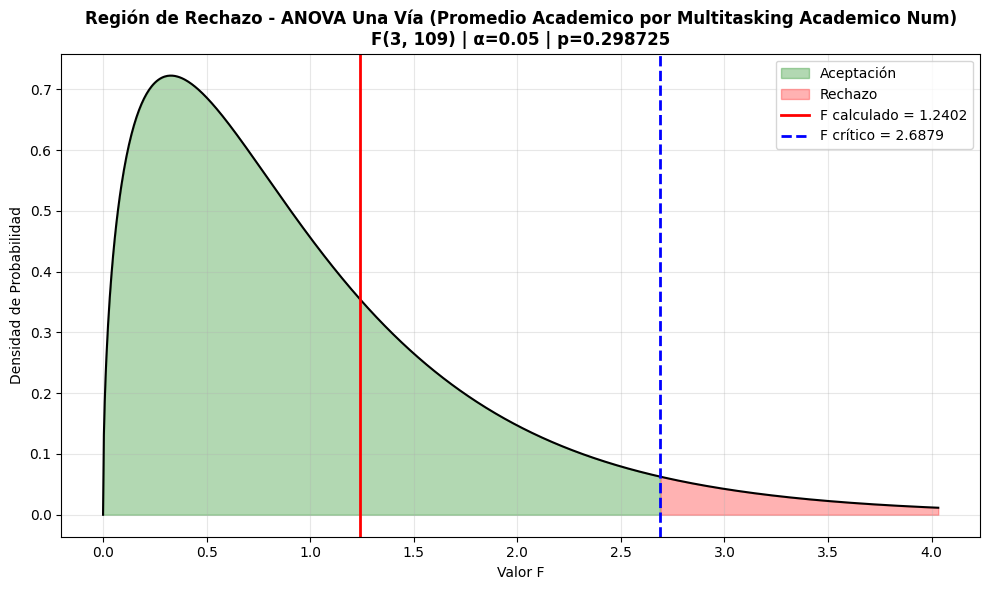

ANÁLISIS COMPLETO FINALIZADO


In [21]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================================
# DATOS DEL PROBLEMA (Adaptado para usar el DataFrame 'df' del Excel)
# ============================================================================

# Asegurarse de que las columnas existan y no tengan NaN para el ANOVA
if 'promedio_academico' not in df.columns or 'multitasking_academico_num' not in df.columns:
    print("Error: Las columnas 'promedio_academico' o 'multitasking_academico_num' no se encontraron en el DataFrame.")
    # Crear un DataFrame vacío para evitar errores posteriores en el script
    df_analysis = pd.DataFrame({'promedio_academico': [], 'multitasking_academico_num': []})
else:
    df_analysis = df[['promedio_academico', 'multitasking_academico_num']].dropna().copy()
    if df_analysis.empty:
        print("Advertencia: No hay datos suficientes después de eliminar NaNs para el ANOVA.")

# Variables para el ANOVA
dependent_var = 'promedio_academico'
grouping_var = 'multitasking_academico_num'

multitasking_levels = df_analysis[grouping_var].unique()

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

data_for_anova = [df_analysis[dependent_var][df_analysis[grouping_var] == level].values for level in multitasking_levels]
n_grupos = len(multitasking_levels)
n_obs = [len(g) for g in data_for_anova]
n_total = sum(n_obs)

media_global = df_analysis[dependent_var].mean()
medias_multitasking = df_analysis.groupby(grouping_var)[dependent_var].mean().values

print("DATOS PARA ANOVA (Primeras 5 filas del DataFrame de análisis):")
print(df_analysis.head())
print(f"\nMedias de {dependent_var} por Nivel de {grouping_var.replace('_', ' ').title()}:")
for i, level in enumerate(multitasking_levels):
    print(f"  Nivel {level}: {medias_multitasking[i]:.4f}")
print(f"Media Global de {dependent_var.replace('_', ' ').title()}: {media_global:.4f}\n")

# ============================================================================
# ANOVA DE UNA VÍA MANUAL
# ============================================================================

if n_grupos < 2 or n_total == 0:
    print("No hay suficientes grupos o datos para realizar el ANOVA.")
else:
    SCT = np.sum((df_analysis[dependent_var] - media_global)**2)
    SCB = sum([n_obs[i]*(medias_multitasking[i] - media_global)**2 for i in range(n_grupos)])
    SCE = SCT - SCB

    gl_b = n_grupos - 1
    gl_e = n_total - n_grupos
    gl_t = n_total - 1

    CMb = SCB / gl_b if gl_b > 0 else 0
    CMe = SCE / gl_e if gl_e > 0 else 0

    F = CMb / CMe if CMe > 0 else np.nan
    p_value = 1 - stats.f.cdf(F, gl_b, gl_e) if not np.isnan(F) else np.nan
    F_crit = stats.f.ppf(0.95, gl_b, gl_e)

    # ============================================================================
    # TABLA ANOVA
    # ============================================================================

    print("TABLA ANOVA DE UNA VÍA")
    print("="*80)
    print(f"{'Fuente de Variación':<25} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12}")
    print("-"*80)
    print(f"{'Entre Grupos (' + grouping_var.replace('_', ' ').title() + ')':<25} {SCB:>12.4f} {gl_b:>6} {CMb:>12.4f} {F:>12.4f} {p_value:>12.6f}")
    print(f"{'Intra Grupos (Error)':<25} {SCE:>12.4f} {gl_e:>6} {CMe:>12.4f}")
    print(f"{'Total':<25} {SCT:>12.4f} {gl_t:>6}")
    print("="*80)

    # ============================================================================
    # INTERPRETACIÓN ANOVA
    # ============================================================================

    alpha = 0.05
    print(f"\nINTERPRETACIÓN ANOVA (α = {alpha}):")
    print(f"  F calculado = {F:.4f}")
    print(f"  F crítico = {F_crit:.4f}")
    print(f"  Valor-p = {p_value:.6f}")

    if p_value < alpha:
        print(f"  ✓ Hay diferencias significativas entre las medias de {dependent_var.replace('_', ' ')} por nivel de {grouping_var.replace('_', ' ')}.\n")

        # ============================================================================
        # ANÁLISIS POST-HOC DE TUKEY (HSD)
        # ============================================================================

        print("ANÁLISIS POST-HOC DE TUKEY (HSD):")
        tukey_result = pairwise_tukeyhsd(endog=df_analysis[dependent_var], groups=df_analysis[grouping_var], alpha=alpha)
        print(tukey_result)
        print("\nINTERPRETACIÓN TUKEY:")
        print("  Las columnas 'reject' indican si la hipótesis nula (no diferencia entre las medias) se rechaza.")
        print("  'True' significa que hay una diferencia significativa entre los pares de grupos.\n")
    else:
        print(f"  ✗ No hay diferencias significativas entre las medias de {dependent_var.replace('_', ' ')} por nivel de {grouping_var.replace('_', ' ')}.\n")
        print("No se requiere un análisis Post-Hoc de Tukey, ya que el ANOVA no encontró diferencias significativas.")

    # ============================================================================
    # GRÁFICO DE REGIÓN DE RECHAZO
    # ============================================================================

    if not np.isnan(F) and not np.isinf(F) and gl_e > 0 and gl_b > 0:
        x = np.linspace(0, max(F, F_crit)*1.5, 1000)
        y = stats.f.pdf(x, gl_b, gl_e)

        plt.figure(figsize=(10, 6))
        plt.plot(x, y, 'k-', linewidth=1.5)
        plt.fill_between(x[x <= F_crit], y[x <= F_crit], color='green', alpha=0.3, label='Aceptación')
        plt.fill_between(x[x >= F_crit], y[x >= F_crit], color='red', alpha=0.3, label='Rechazo')
        plt.axvline(F, color='red', linewidth=2, label=f'F calculado = {F:.4f}')
        plt.axvline(F_crit, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit:.4f}')
        plt.title(f'Región de Rechazo - ANOVA Una Vía ({dependent_var.replace('_', ' ').title()} por {grouping_var.replace('_', ' ').title()})\nF({gl_b}, {gl_e}) | α={alpha} | p={p_value:.6f}', fontsize=12, fontweight='bold')
        plt.xlabel('Valor F')
        plt.ylabel('Densidad de Probabilidad')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No se puede generar el gráfico de región de rechazo debido a valores F no válidos o grados de libertad insuficientes.")

print("="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)



--- Análisis de Regresión Lineal Simple ---
  Variable Dependiente (Y): Promedio Académico
  Variable Independiente (X): Horas de Uso Celular (No Académico)

Resultados del Modelo (Resumen Estadístico):

                            OLS Regression Results                            
Dep. Variable:     promedio_academico   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.533
Date:                Fri, 22 May 2026   Prob (F-statistic):              0.218
Time:                        03:49:23   Log-Likelihood:                -60.652
No. Observations:                 113   AIC:                             125.3
Df Residuals:                     111   BIC:                             130.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
     

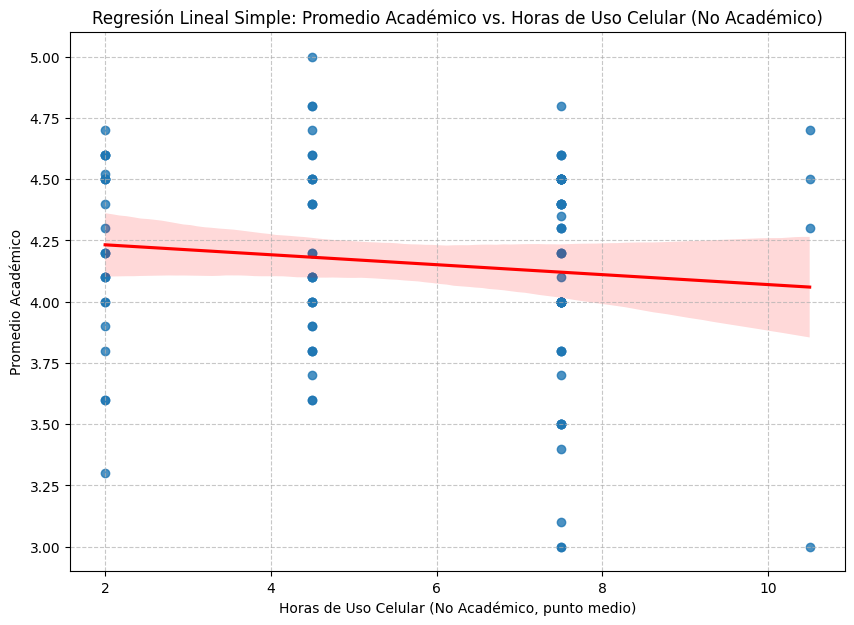

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Definir las variables dependiente (Y) e independiente (X)
# Y = promedio académico
# X = horas de uso del celular no académico

# Asegurarse de que las columnas existan y no tengan nulos para la regresión
if 'horas_uso_celular_no_academico_num' in df.columns and 'promedio_academico' in df.columns:
    # Limpiar cualquier NaN en las variables relevantes antes de la regresión
    df_reg = df[['horas_uso_celular_no_academico_num', 'promedio_academico']].dropna()

    if not df_reg.empty:
        X = df_reg['horas_uso_celular_no_academico_num']
        y = df_reg['promedio_academico']

        # Añadir constante para el intercepto
        X = sm.add_constant(X)

        # Modelo de regresión lineal (Mínimos Cuadrados Ordinarios - OLS)
        model = sm.OLS(y, X)
        results = model.fit()

        print("\n--- Análisis de Regresión Lineal Simple ---")
        print("  Variable Dependiente (Y): Promedio Académico")
        print("  Variable Independiente (X): Horas de Uso Celular (No Académico)")
        print("\nResultados del Modelo (Resumen Estadístico):\n")
        print(results.summary())

        # --- Interpretación Académica y Conclusión ---
        alpha = 0.05
        print("\n--- Interpretación Académica y Conclusión (α = 0.05) ---")

        # Coeficiente de la variable independiente (horas de uso del celular)
        p_value_horas = results.pvalues['horas_uso_celular_no_academico_num']
        coef_horas = results.params['horas_uso_celular_no_academico_num']
        conf_int_horas = results.conf_int().loc['horas_uso_celular_no_academico_num']
        intercept = results.params['const']

        print(f"  Modelo lineal ajustado: Y = {intercept:.3f} + ({coef_horas:.3f})X")
        print(f"  Donde: X = horas de uso del celular no académico, Y = promedio académico.")

        print(f"  Hipótesis Nula (H0): El coeficiente de las horas de uso del celular es cero (no hay relación lineal).")
        print(f"  Hipótesis Alternativa (H1): El coeficiente de las horas de uso del celular no es cero (existe una relación lineal).")
        print(f"  p-valor para Horas de Uso Celular no Académico = {p_value_horas:.4f}")

        if p_value_horas < alpha:
            print(f"  Conclusión: Se rechaza la hipótesis nula. Las horas de uso del celular no académico tienen un efecto lineal significativo en el promedio académico.")
            print(f"  Por cada hora adicional de celular, el promedio académico cambia en {coef_horas:.3f} puntos (IC 95%: [{conf_int_horas[0]:.3f}, {conf_int_horas[1]:.3f}]).")
            if coef_horas < 0:
                print("  La relación es negativa: a mayor uso, menor promedio académico.")
            else:
                print("  La relación es positiva: a mayor uso, mayor promedio académico.")
        else:
            print(f"  Conclusión: No se rechaza la hipótesis nula. Las horas de uso del celular no académico no tienen un efecto lineal significativo en el promedio académico (p >= 0.05).")
            print(f"  (Esto significa que el coeficiente de {coef_horas:.3f} no es estadísticamente diferente de cero con un nivel de confianza del 95%).")

        # Coeficiente de determinación R-cuadrado
        r_squared = results.rsquared
        print(f"  R-cuadrado = {r_squared:.4f} ({r_squared*100:.2f}%).")
        print(f"  Esto significa que el {r_squared*100:.2f}% de la varianza en el promedio académico es explicado por las horas de uso del celular no académico.")
        if r_squared < 0.05:
            print("  El celular explica muy poco del rendimiento académico.")
        elif r_squared < 0.25:
            print("  El celular explica una porción pequeña pero notable del rendimiento académico.")
        else:
            print("  El celular explica una parte considerable del rendimiento académico.")

        # --- Gráfico de Regresión ---
        plt.figure(figsize=(10, 7))
        sns.regplot(x=df_reg['horas_uso_celular_no_academico_num'], y=df_reg['promedio_academico'], line_kws={'color':'red'})
        plt.title('Regresión Lineal Simple: Promedio Académico vs. Horas de Uso Celular (No Académico)')
        plt.xlabel('Horas de Uso Celular (No Académico, punto medio)')
        plt.ylabel('Promedio Académico')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()
    else:
        print("Advertencia: No hay suficientes datos no nulos en las columnas 'horas_uso_celular_no_academico_num' y 'promedio_academico' para realizar la regresión lineal. Asegúrese de que estas columnas estén correctamente mapeadas y no contengan solo NaN después de la limpieza.")
else:
    print("Advertencia: Las columnas 'horas_uso_celular_no_academico_num' o 'promedio_academico' no se encontraron en el DataFrame. Asegúrese de que el preprocesamiento de datos se haya ejecutado correctamente.")